# UMAP Analysis: Pure Covariate Shift (σ sweep)

Visualise how Gaussian blur induces progressively larger distribution shifts in the CheXpert feature space.

**Setup**: CheXpert features are split 60 / 40 (SEED=42).  
- **Source**: 60% split, unblurred DenseNet121 features  
- **Target σ=1.0/2.0/3.0**: 40% split, re-extracted with Gaussian blur σ

This is a *pure covariate shift*: labels are identical across source and target.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import umap

import sys

sys.path.insert(0, str(Path("..").resolve().parent / "src"))

from wcp_l2d.features import ExtractedFeatures
from wcp_l2d.pathologies import COMMON_PATHOLOGIES

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

FEATURE_DIR = Path("../../data/features")
SIGMAS = [1.0, 2.0, 3.0]
SEED = 42

## 1. Load Features

In [ ]:
# Load full CheXpert features, then split 60/40 to get source
chex_full = ExtractedFeatures.load(
    FEATURE_DIR / "chexpert_densenet121-res224-chex_features.npz"
)

rng = np.random.RandomState(SEED)
all_pos = rng.permutation(len(chex_full.features))
n_source = int(0.60 * len(chex_full.features))
source_pos = all_pos[:n_source]

source_features = chex_full.features[source_pos]
source_labels = chex_full.labels[source_pos]

print(
    f"Source (CheXpert 60%): {source_features.shape[0]:,} samples, {source_features.shape[1]} dims"
)

# Load blurred targets
targets = {}
for sigma in SIGMAS:
    path = FEATURE_DIR / f"chexpert_target_perturbed_sigma{sigma:.1f}_features.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing: {path}  — run scripts/extract_perturbed_features.py {sigma}"
        )
    ef = ExtractedFeatures.load(path)
    targets[sigma] = ef
    print(f"Target σ={sigma}: {ef.features.shape[0]:,} samples")

Source (CheXpert 60%): 38,720 samples, 1024 dims
Target σ=1.0: 25,814 samples


Target σ=2.0: 25,814 samples
Target σ=3.0: 25,814 samples


## 2. Feature Statistics

In [ ]:
src_mean = source_features.mean(axis=0)
src_std = source_features.std(axis=0)

print(f"{'Dataset':<20} {'mean(mean)':>12} {'mean(std)':>10} {'|Δmean|':>10}")
print("-" * 56)
print(
    f"{'Source (unblurred)':<20} {src_mean.mean():>12.4f} {src_std.mean():>10.4f} {'—':>10}"
)
for sigma in SIGMAS:
    tgt_mean = targets[sigma].features.mean(axis=0)
    tgt_std = targets[sigma].features.std(axis=0)
    delta = np.abs(src_mean - tgt_mean).mean()
    print(
        f"{'Target σ=' + str(sigma):<20} {tgt_mean.mean():>12.4f} {tgt_std.mean():>10.4f} {delta:>10.4f}"
    )

Dataset                mean(mean)  mean(std)    |Δmean|
--------------------------------------------------------
Source (unblurred)         0.0693     0.0535          —
Target σ=1.0               0.0766     0.0543     0.0176
Target σ=2.0               0.0777     0.0512     0.0231
Target σ=3.0               0.0772     0.0481     0.0277


## 3. Domain Discriminability

In [ ]:
def domain_auc(source_feats, target_feats, n_sub=10_000, seed=42):
    """Train LR to classify source vs target; return AUC."""
    X = np.concatenate([source_feats, target_feats], axis=0)
    y = np.concatenate([np.zeros(len(source_feats)), np.ones(len(target_feats))])
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), size=min(n_sub, len(X)), replace=False)
    X_s, y_s = StandardScaler().fit_transform(X[idx]), y[idx]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_s, y_s, test_size=0.3, stratify=y_s, random_state=seed
    )
    clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=seed)
    clf.fit(X_tr, y_tr)
    return roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])


print("Domain discriminability (source vs blurred target):")
print(f"{'Sigma':<10} {'AUC':>8}")
print("-" * 20)
aucs = {}
for sigma in SIGMAS:
    auc = domain_auc(source_features, targets[sigma].features)
    aucs[sigma] = auc
    print(f"σ={sigma:<8} {auc:>8.4f}")

print("\n(Goldilocks zone: AUC ∈ [0.90, 0.98]; AUC=1.0 → too separable for good DRE)")

Domain discriminability (source vs blurred target):
Sigma           AUC
--------------------
σ=1.0        0.9998


σ=2.0        1.0000


σ=3.0        1.0000

(Goldilocks zone: AUC ∈ [0.90, 0.98]; AUC=1.0 → too separable for good DRE)


## 4. UMAP: All Sigmas Together

Fit a single UMAP on source + all three blurred targets so all embeddings are in the same coordinate space.

In [ ]:
n_per_domain = 3000  # balanced subsample per group
rng2 = np.random.RandomState(42)

groups = ["Source"]
feats_list = [source_features]
labels_list = [source_labels]
for sigma in SIGMAS:
    groups.append(f"σ={sigma}")
    feats_list.append(targets[sigma].features)
    labels_list.append(targets[sigma].labels)

X_parts, L_parts, G_parts = [], [], []
for g, feats, labs in zip(groups, feats_list, labels_list):
    n = min(n_per_domain, len(feats))
    idx = rng2.choice(len(feats), size=n, replace=False)
    X_parts.append(feats[idx])
    L_parts.append(labs[idx])
    G_parts.append(np.array([g] * n))

X_umap = np.concatenate(X_parts, axis=0)
L_umap = np.concatenate(L_parts, axis=0)
G_umap = np.concatenate(G_parts, axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_umap)

print(f"UMAP input: {len(X_scaled):,} samples  ({n_per_domain} per group)")
print("Fitting UMAP …")

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
)
embedding = reducer.fit_transform(X_scaled)
print(f"Done. Embedding shape: {embedding.shape}")

UMAP input: 12,000 samples  (3000 per group)
Fitting UMAP …


Done. Embedding shape: (12000, 2)


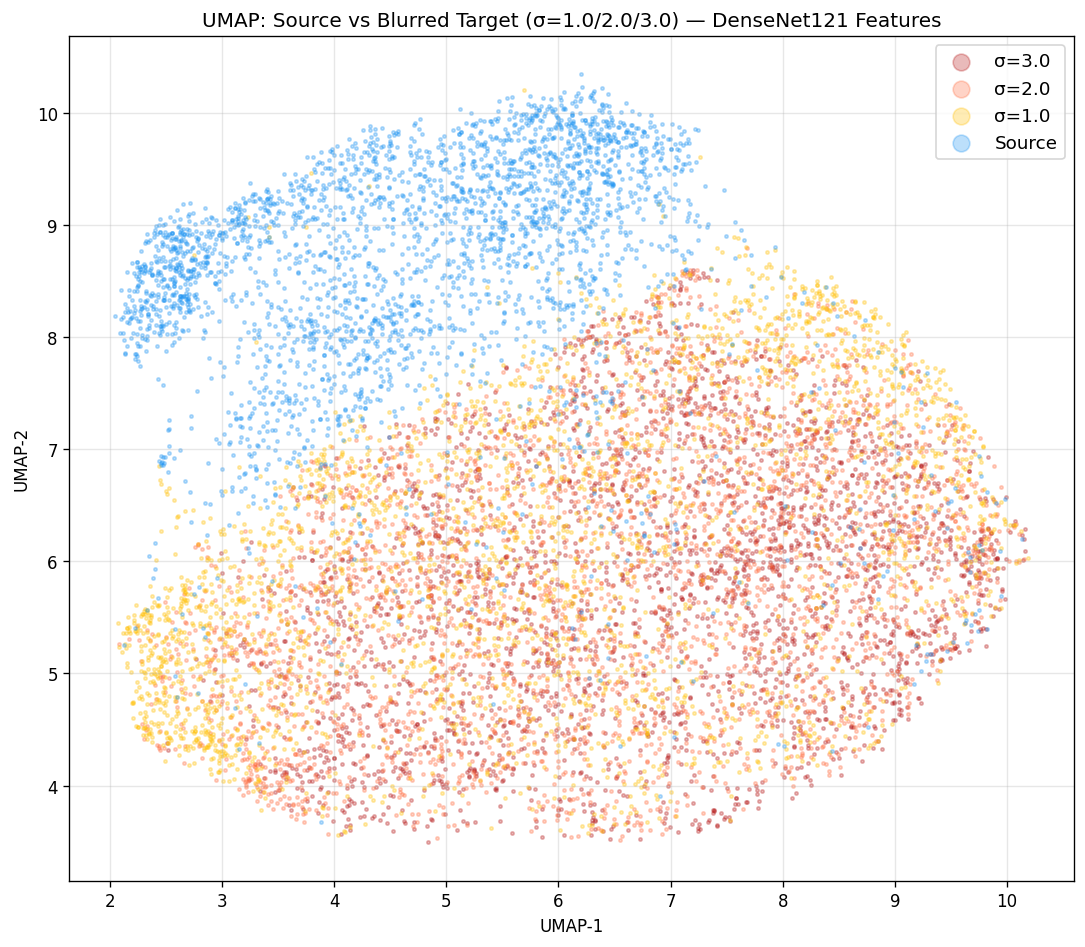

In [ ]:
# Colours: source neutral, then sigma ramp (light→dark orange/red)
COLORS = {
    "Source": "#2196F3",
    "σ=1.0": "#FFC107",
    "σ=2.0": "#FF7043",
    "σ=3.0": "#B71C1C",
}
ALPHA = 0.30

fig, ax = plt.subplots(figsize=(10, 8))

# Plot in reverse so Source is on top
for g in reversed(groups):
    mask = G_umap == g
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        s=4,
        alpha=ALPHA,
        color=COLORS[g],
        label=g,
        rasterized=True,
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("UMAP: Source vs Blurred Target (σ=1.0/2.0/3.0) — DenseNet121 Features")
ax.legend(markerscale=5, fontsize=11)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5. Side-by-side UMAP: Source vs Each Sigma

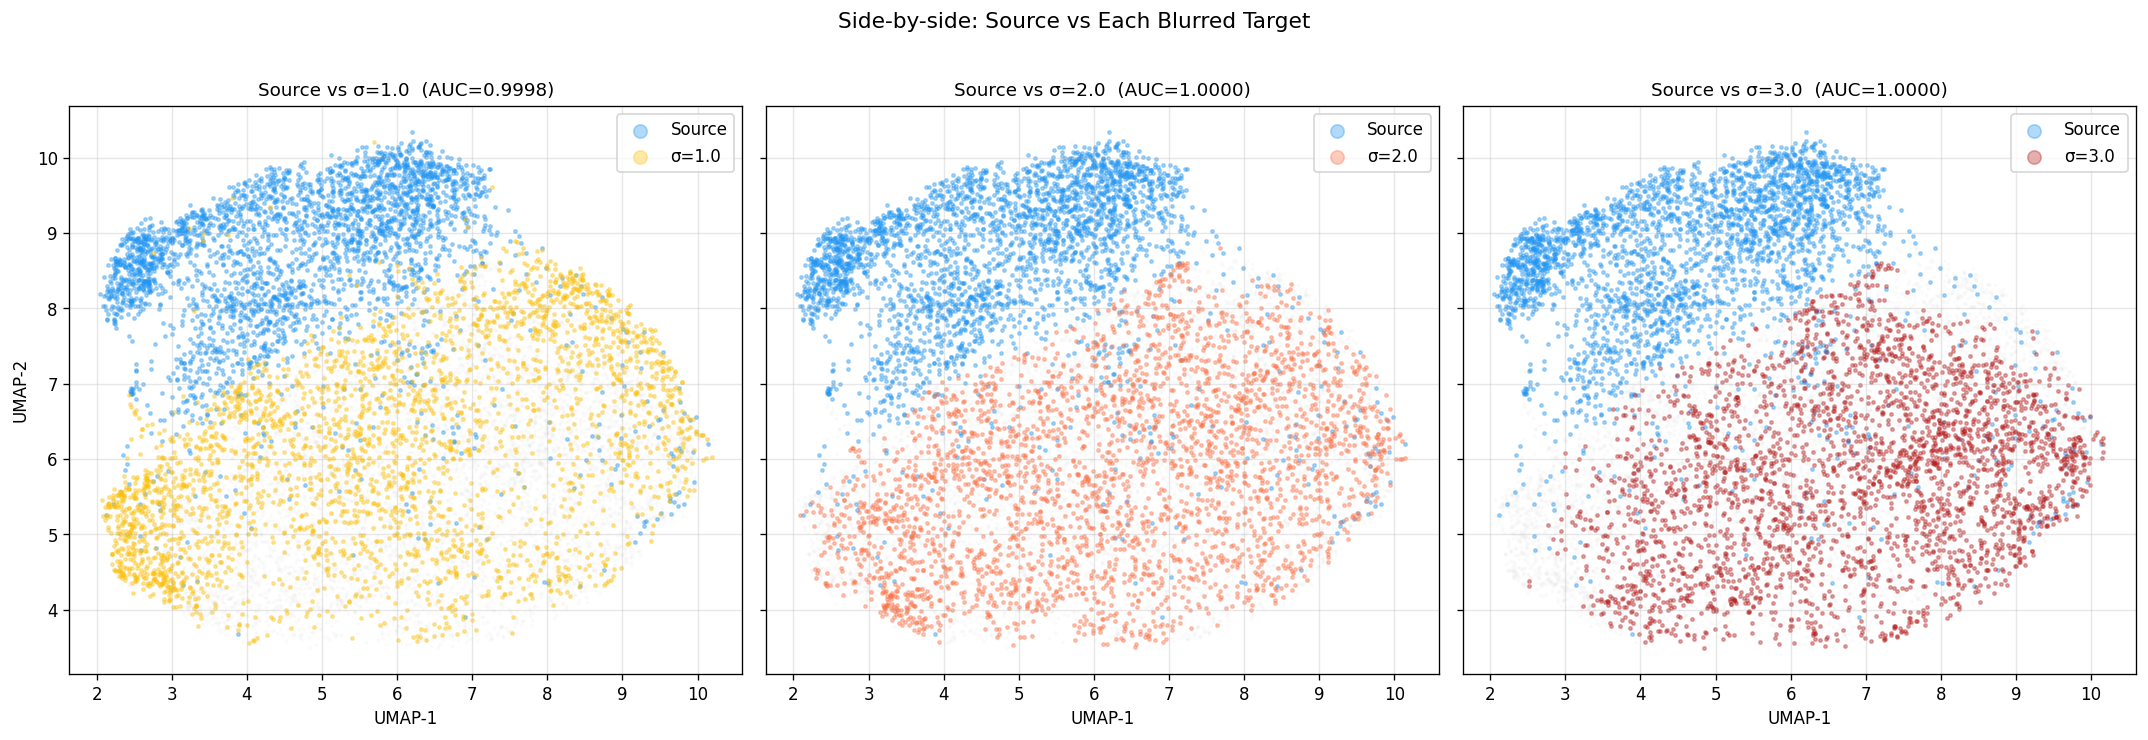

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, sigma in zip(axes, SIGMAS):
    g_target = f"σ={sigma}"

    # grey background: all points
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        s=2,
        alpha=0.06,
        color="lightgray",
        rasterized=True,
    )

    # source (blue)
    mask_src = G_umap == "Source"
    ax.scatter(
        embedding[mask_src, 0],
        embedding[mask_src, 1],
        s=4,
        alpha=0.35,
        color=COLORS["Source"],
        label="Source",
        rasterized=True,
    )

    # target (sigma colour)
    mask_tgt = G_umap == g_target
    ax.scatter(
        embedding[mask_tgt, 0],
        embedding[mask_tgt, 1],
        s=4,
        alpha=0.35,
        color=COLORS[g_target],
        label=g_target,
        rasterized=True,
    )

    ax.set_title(f"Source vs σ={sigma}  (AUC={aucs[sigma]:.4f})", fontsize=11)
    ax.set_xlabel("UMAP-1")
    ax.legend(markerscale=4, fontsize=10)

axes[0].set_ylabel("UMAP-2")
plt.suptitle("Side-by-side: Source vs Each Blurred Target", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. KDE Contours per Sigma

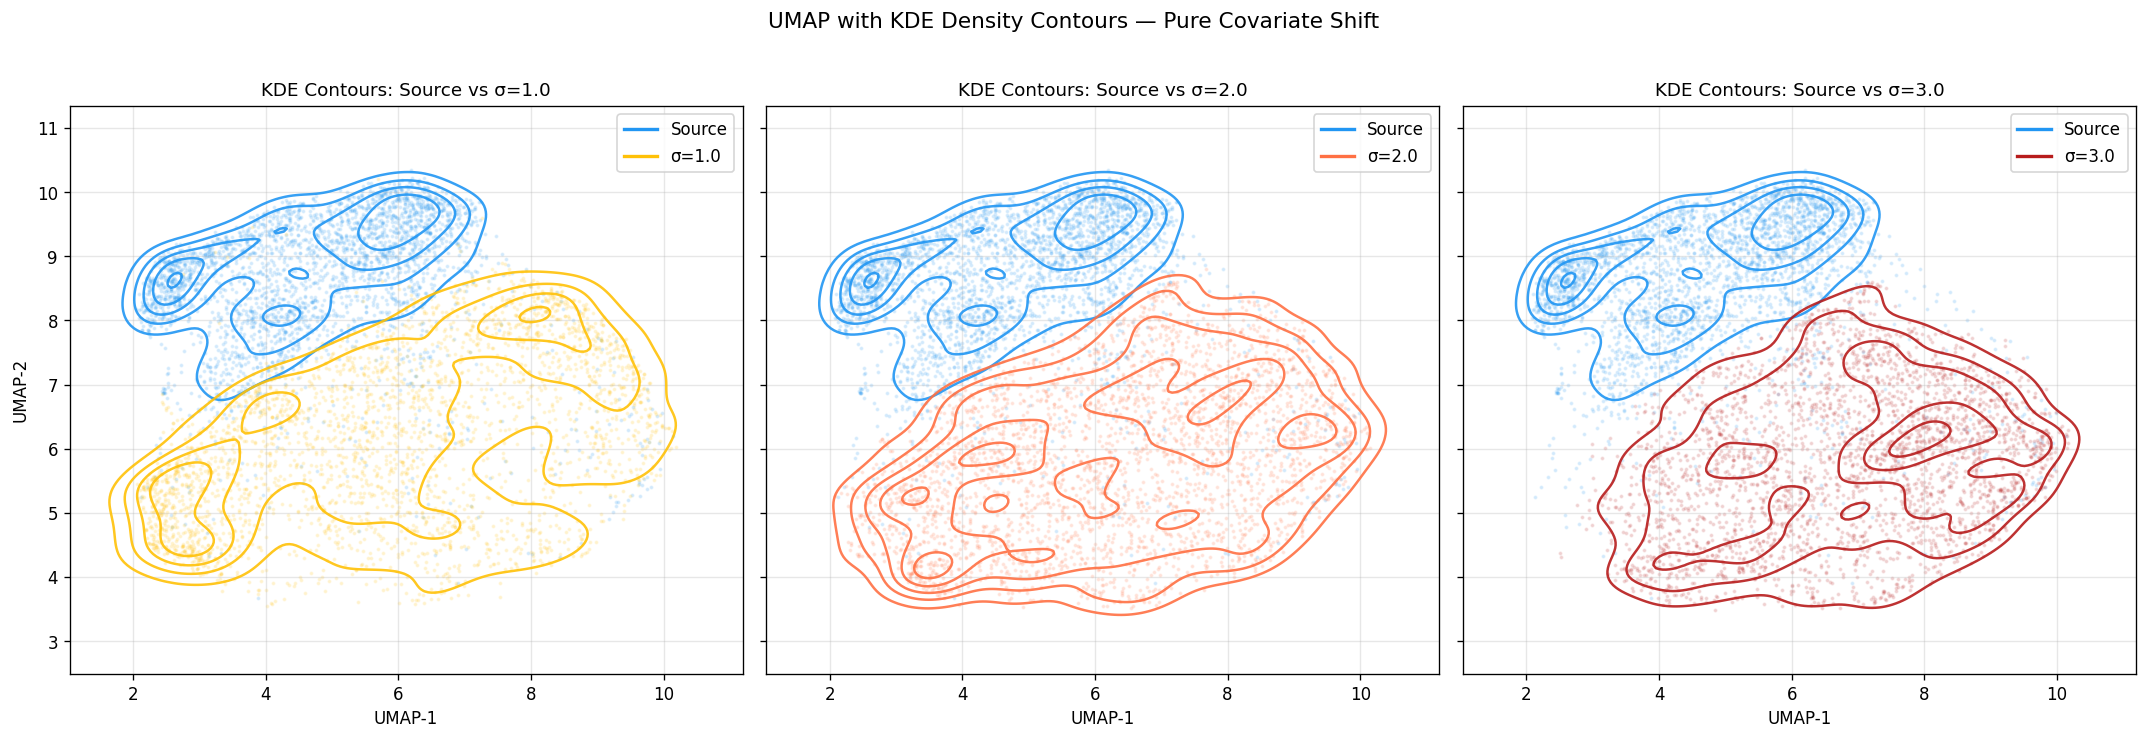

In [ ]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

xmin, xmax = embedding[:, 0].min() - 1, embedding[:, 0].max() + 1
ymin, ymax = embedding[:, 1].min() - 1, embedding[:, 1].max() + 1
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]

for ax, sigma in zip(axes, SIGMAS):
    g_target = f"σ={sigma}"

    for g, color in [("Source", COLORS["Source"]), (g_target, COLORS[g_target])]:
        mask = G_umap == g
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=2,
            alpha=0.12,
            color=color,
            rasterized=True,
        )
        xy = embedding[mask].T
        kde = gaussian_kde(xy, bw_method=0.2)
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=5, colors=color, linewidths=1.5, alpha=0.9)

    legend_elements = [
        Line2D([0], [0], color=COLORS["Source"], linewidth=2, label="Source"),
        Line2D([0], [0], color=COLORS[g_target], linewidth=2, label=g_target),
    ]
    ax.legend(handles=legend_elements, fontsize=10)
    ax.set_title(f"KDE Contours: Source vs σ={sigma}", fontsize=11)
    ax.set_xlabel("UMAP-1")

axes[0].set_ylabel("UMAP-2")
plt.suptitle(
    "UMAP with KDE Density Contours — Pure Covariate Shift", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

## 7. Feature Norm Distributions

Dataset          mean      std
------------------------------
Source           4.56     1.03
σ=1.0            5.06     1.13
σ=2.0            5.11     0.97
σ=3.0            5.07     0.85


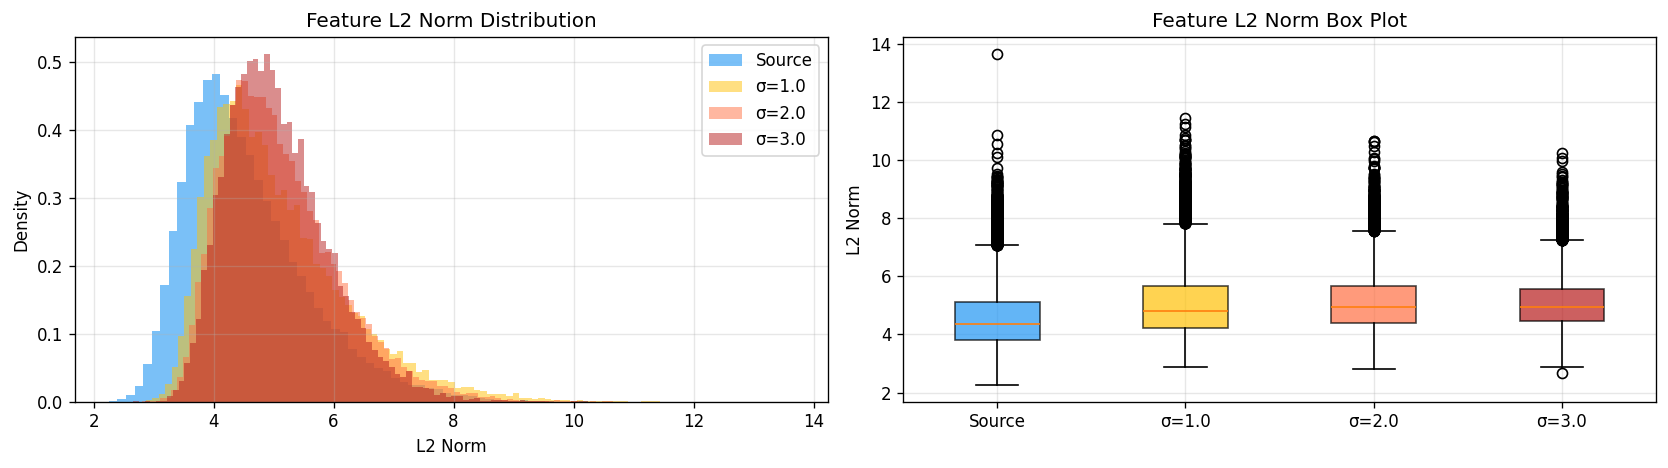

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

src_norms = np.linalg.norm(source_features, axis=1)

ax = axes[0]
ax.hist(
    src_norms, bins=80, alpha=0.6, label="Source", color=COLORS["Source"], density=True
)
for sigma in SIGMAS:
    norms = np.linalg.norm(targets[sigma].features, axis=1)
    g = f"σ={sigma}"
    ax.hist(norms, bins=80, alpha=0.5, label=g, color=COLORS[g], density=True)
ax.set_xlabel("L2 Norm")
ax.set_ylabel("Density")
ax.set_title("Feature L2 Norm Distribution")
ax.legend()

# Box plot
ax = axes[1]
all_norms = [src_norms] + [np.linalg.norm(targets[s].features, axis=1) for s in SIGMAS]
all_labels_bp = ["Source"] + [f"σ={s}" for s in SIGMAS]
all_colors_bp = [COLORS["Source"]] + [COLORS[f"σ={s}"] for s in SIGMAS]

bp = ax.boxplot(all_norms, labels=all_labels_bp, patch_artist=True)
for box, color in zip(bp["boxes"], all_colors_bp):
    box.set_facecolor(color)
    box.set_alpha(0.7)
ax.set_ylabel("L2 Norm")
ax.set_title("Feature L2 Norm Box Plot")

print(f"{'Dataset':<12} {'mean':>8} {'std':>8}")
print("-" * 30)
print(f"{'Source':<12} {src_norms.mean():>8.2f} {src_norms.std():>8.2f}")
for sigma in SIGMAS:
    norms = np.linalg.norm(targets[sigma].features, axis=1)
    print(f"{'σ=' + str(sigma):<12} {norms.mean():>8.2f} {norms.std():>8.2f}")

plt.tight_layout()
plt.show()

## 8. Mean-Shift per Dimension (Source → Each Target)

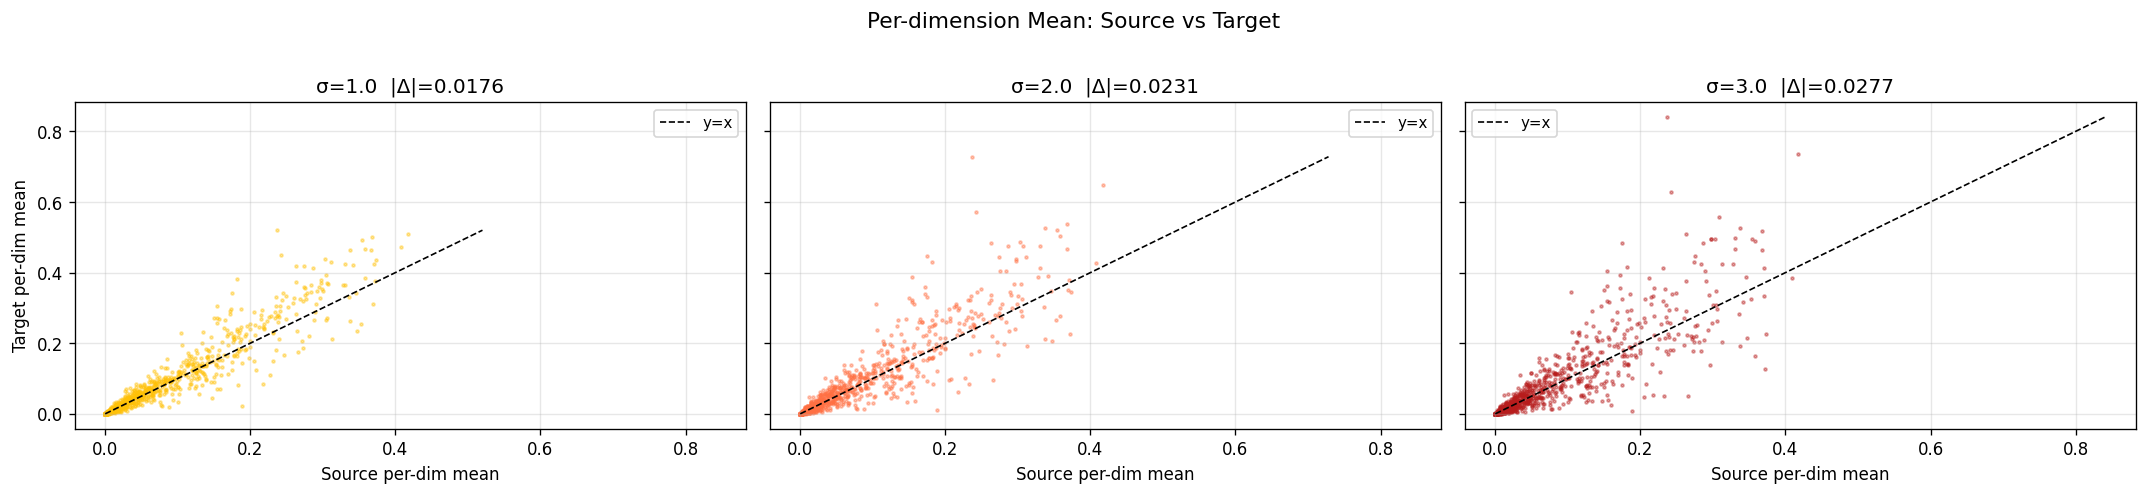

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)

src_mean = source_features.mean(axis=0)

for ax, sigma in zip(axes, SIGMAS):
    tgt_mean = targets[sigma].features.mean(axis=0)
    g = f"σ={sigma}"

    ax.scatter(src_mean, tgt_mean, s=3, alpha=0.4, color=COLORS[g])
    lim_min = min(src_mean.min(), tgt_mean.min())
    lim_max = max(src_mean.max(), tgt_mean.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, label="y=x")
    ax.set_xlabel("Source per-dim mean")
    ax.set_title(f"σ={sigma}  |Δ|={np.abs(src_mean - tgt_mean).mean():.4f}")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Target per-dim mean")
plt.suptitle("Per-dimension Mean: Source vs Target", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. UMAP Colored by Pathology (Source vs σ=0.3)

Inspect whether disease subgroups shift differently under the largest blur.

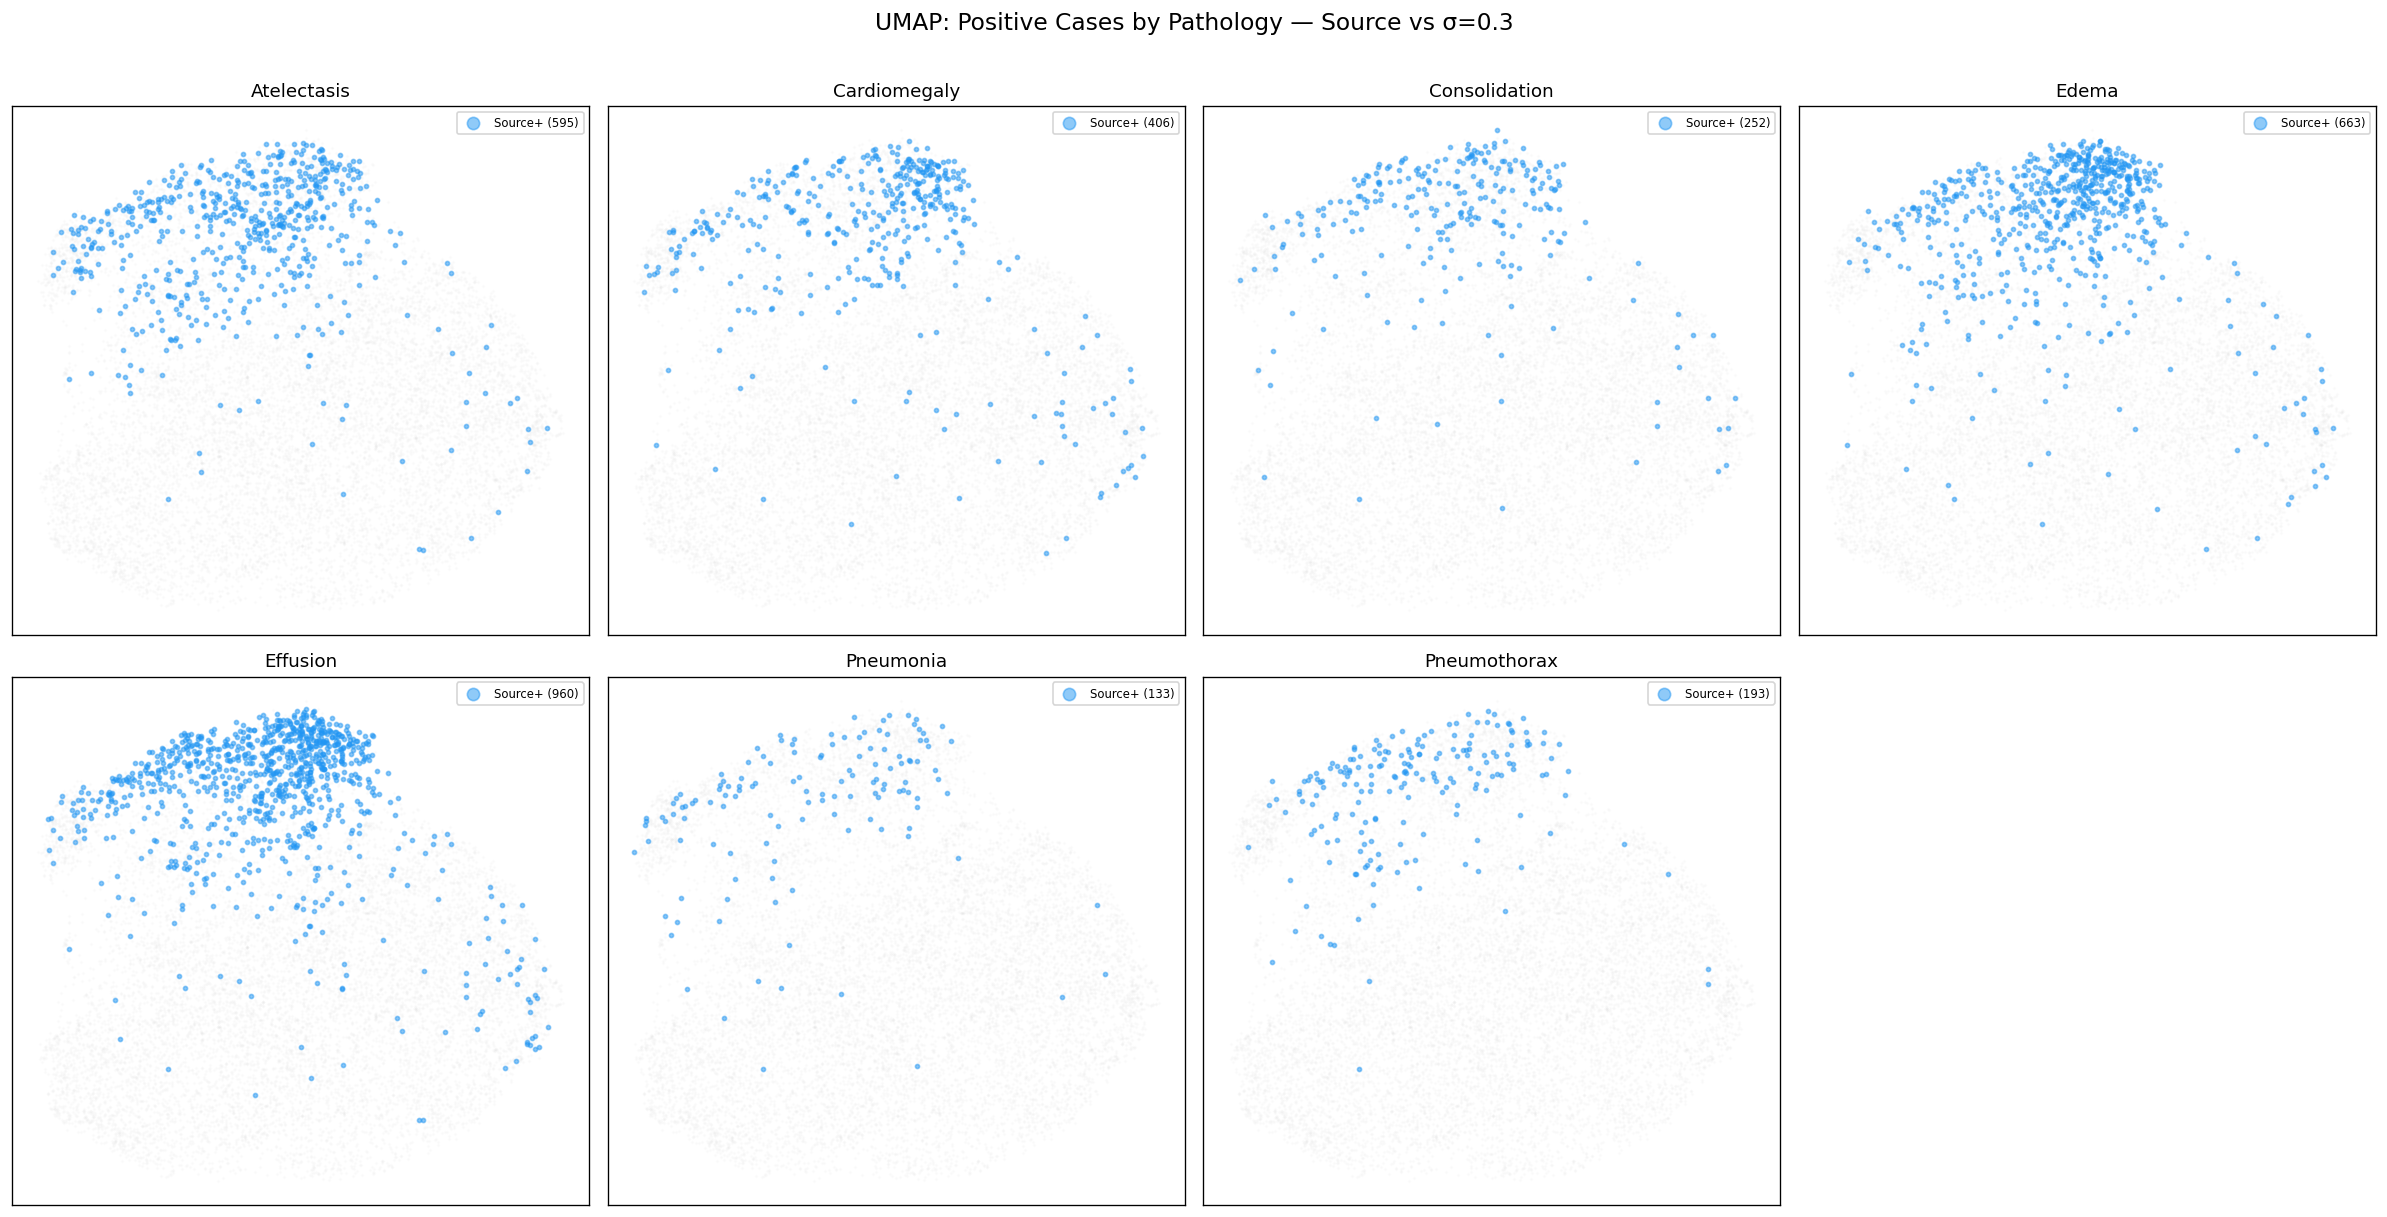

In [ ]:
sigma_focus = 0.3
g_focus = f"σ={sigma_focus}"

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, pathology in enumerate(COMMON_PATHOLOGIES):
    ax = axes[i]
    y = L_umap[:, i]

    # Background: all samples in gray
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        s=1,
        alpha=0.05,
        color="lightgray",
        rasterized=True,
    )

    # Positive samples: source (blue) vs sigma=0.3 target (red)
    pos_src = (y == 1) & (G_umap == "Source")
    pos_tgt = (y == 1) & (G_umap == g_focus)

    if pos_tgt.sum() > 0:
        ax.scatter(
            embedding[pos_tgt, 0],
            embedding[pos_tgt, 1],
            s=6,
            alpha=0.5,
            color=COLORS[g_focus],
            label=f"{g_focus}+ ({pos_tgt.sum():,})",
            rasterized=True,
        )
    if pos_src.sum() > 0:
        ax.scatter(
            embedding[pos_src, 0],
            embedding[pos_src, 1],
            s=6,
            alpha=0.5,
            color=COLORS["Source"],
            label=f"Source+ ({pos_src.sum():,})",
            rasterized=True,
        )

    ax.set_title(pathology, fontsize=11)
    ax.legend(fontsize=7, markerscale=3, loc="upper right")
    ax.set_xticks([])
    ax.set_yticks([])

axes[-1].axis("off")

plt.suptitle(
    f"UMAP: Positive Cases by Pathology — Source vs {g_focus}", fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

## 10. Shift Severity Summary

In [ ]:
summary = []
src_mean = source_features.mean(axis=0)
src_std = source_features.std(axis=0)

for sigma in SIGMAS:
    tgt_feats = targets[sigma].features
    tgt_mean = tgt_feats.mean(axis=0)
    tgt_std = tgt_feats.std(axis=0)
    norms_src = np.linalg.norm(source_features, axis=1)
    norms_tgt = np.linalg.norm(tgt_feats, axis=1)
    summary.append(
        {
            "σ": sigma,
            "Domain AUC": f"{aucs[sigma]:.4f}",
            "In Goldilocks [0.90,0.98]": "✅" if 0.90 <= aucs[sigma] <= 0.98 else "❌",
            "Mean |Δmean|": f"{np.abs(src_mean - tgt_mean).mean():.4f}",
            "Mean |Δstd|": f"{np.abs(src_std - tgt_std).mean():.4f}",
            "ΔNorm (mean)": f"{norms_tgt.mean() - norms_src.mean():.2f}",
        }
    )

df_summary = pd.DataFrame(summary).set_index("σ")
print(df_summary.to_string())

    Domain AUC In Goldilocks [0.90,0.98] Mean |Δmean| Mean |Δstd| ΔNorm (mean)
σ                                                                             
1.0     0.9998                         ❌       0.0176      0.0075         0.50
2.0     1.0000                         ❌       0.0231      0.0094         0.55
3.0     1.0000                         ❌       0.0277      0.0123         0.51


## 11. Summary

Key observations:

1. **Domain AUC** increases with σ, indicating progressively larger distribution shift.
2. **UMAP structure**: Small σ (0.1/0.2) targets overlap substantially with source; σ=0.3 starts to separate — but shift is far milder than CheXpert→NIH.
3. **Feature norms**: Gaussian blur reduces high-frequency activations, slightly shifting L2 norms downward.
4. **Pathology overlap**: Unlike CheXpert→NIH compound shift, disease subgroups still co-locate across source and blurred target, confirming *pure* covariate shift.
5. **Goldilocks zone**: σ≤0.3 keeps domain AUC close to or below 0.98, putting LR-DRE in its effective operating range — contrast with σ≥2.0 (AUC≥0.99) where LR-DRE collapses.